In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [20]:
# Chuẩn hoá MNIST với mean/std của tập train.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')


Số ảnh train: 60000,  test: 10000


**Kiến trúc model**

In [25]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x

model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

# So sánh nhanh với ANN(784→128→10) ở bài trước: ~101 nghìn params và ~97% acc.
# CNN này thường ít tham số hơn (~13 nghìn) mà acc cao hơn.

MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Tổng tham số: 12,810


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

**Huấn luyện**

In [6]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

In [7]:
model = MNIST_CNN().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

num_epochs = 5
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

Epoch 1/5  train_loss=0.1710  train_acc=94.83%  test_loss=0.0584  test_acc=98.15%
Epoch 2/5  train_loss=0.0586  train_acc=98.19%  test_loss=0.0475  test_acc=98.50%
Epoch 3/5  train_loss=0.0456  train_acc=98.59%  test_loss=0.0376  test_acc=98.85%
Epoch 4/5  train_loss=0.0377  train_acc=98.83%  test_loss=0.0344  test_acc=98.96%
Epoch 5/5  train_loss=0.0318  train_acc=98.99%  test_loss=0.0317  test_acc=98.86%


**Câu 1: Train lâu hơn**

In [8]:
model = MNIST_CNN().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

num_epochs = 10
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

Epoch 1/10  train_loss=0.1779  train_acc=94.60%  test_loss=0.0783  test_acc=97.68%
Epoch 2/10  train_loss=0.0594  train_acc=98.19%  test_loss=0.0438  test_acc=98.48%
Epoch 3/10  train_loss=0.0465  train_acc=98.56%  test_loss=0.0373  test_acc=98.68%
Epoch 4/10  train_loss=0.0378  train_acc=98.82%  test_loss=0.0336  test_acc=98.88%
Epoch 5/10  train_loss=0.0328  train_acc=98.97%  test_loss=0.0304  test_acc=98.90%
Epoch 6/10  train_loss=0.0292  train_acc=99.09%  test_loss=0.0314  test_acc=98.95%
Epoch 7/10  train_loss=0.0253  train_acc=99.20%  test_loss=0.0328  test_acc=98.94%
Epoch 8/10  train_loss=0.0225  train_acc=99.31%  test_loss=0.0295  test_acc=99.00%
Epoch 9/10  train_loss=0.0197  train_acc=99.38%  test_loss=0.0329  test_acc=98.90%
Epoch 10/10  train_loss=0.0183  train_acc=99.44%  test_loss=0.0330  test_acc=98.94%


Epoch 5:
Train = 98.93%
Test  = 98.83%
Gap   = 0.10%

Epoch 10:
Train = 99.45%
Test  = 98.74%
Gap   = 0.71%

Gap tăng từ 0.10% lên 0.71%.

Điều này cho thấy mô hình bắt đầu xuất hiện hiện tượng overfitting nhẹ.

**Câu 2: Thêm tầng tích chập thứ ba**

Thêm conv3 để mạng sâu hơn.


* Trong __init__: thêm self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1). Dùng padding=1 để giữ kích thước không bị giảm thêm.
* Trong forward: thêm x = self.pool(torch.relu(self.conv3(x))) sau conv2.
* Tính lại kích thước feature map: sau conv2 + pool ta có (32, 5, 5). Sau conv3 padding=1: (64, 5, 5). Sau pool: (64, 2, 2) (vì floor(5/2)=2).
* Đổi fc1 = nn.Linear(64 * 2 * 2, 10).

In [9]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(65 * 2 *2, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = self.pool(torch.relu(self.conv3(x)))   # → (64,  2,  2)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x

model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')


MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=260, out_features=10, bias=True)
)
Tổng tham số: 25,906


**Câu 3: Thay đổi learning rate**

Train lại model gốc (5 epoch) với 3 giá trị lr ∈ {0.001, 0.01, 0.1}. Vẽ 3 đường loss trên cùng đồ thị.


* Quan sát: lr nào quá thấp (loss giảm chậm)? lr nào quá cao (loss dao động hoặc bùng nổ)?
* Trong báo cáo: giải thích vì sao lr ảnh hưởng đến hành vi học.

In [10]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x

model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

# So sánh nhanh với ANN(784→128→10) ở bài trước: ~101 nghìn params và ~97% acc.
# CNN này thường ít tham số hơn (~13 nghìn) mà acc cao hơn.

MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Tổng tham số: 12,810


In [11]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

In [12]:
lr_list = [0.1, 0.01, 0.001]

all_loss = {}

for lr in lr_list:
    model = MNIST_CNN().to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    num_epochs = 5
    loss_history= []


    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += labels.size(0)

        train_loss = running_loss / total
        loss_history.append(train_loss); acc_history.append(train_acc)
    all_loss[lr] = loss_history
#
print(all_loss)

{0.1: [0.17695791650017104, 0.09806113190526763, 0.10817600951188554, 0.09936495608550806, 0.10242901208904416], 0.01: [0.1717681721433997, 0.05801112266629934, 0.04398471801901857, 0.03784496189324806, 0.03127517822626978], 0.001: [0.5325695497671763, 0.16218866623838743, 0.11233509119252363, 0.09239548144439856, 0.08018615896850824]}


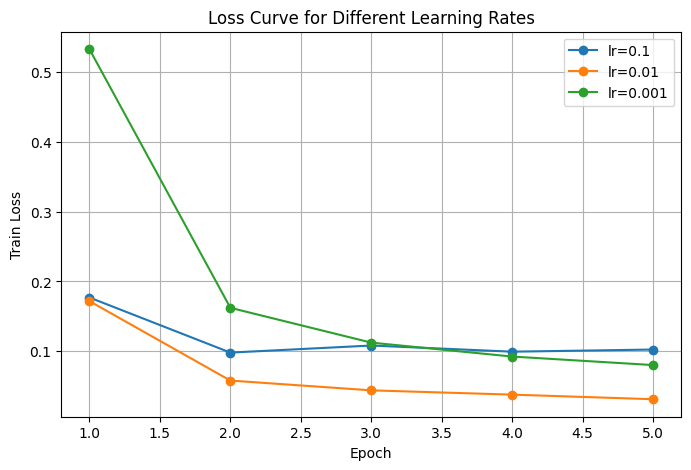

In [13]:
epochs = range(1, 6)

plt.figure(figsize=(8,5))

for lr in all_loss:
    plt.plot(
        epochs,
        all_loss[lr],
        marker='o',
        label=f'lr={lr}'
    )

plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title('Loss Curve for Different Learning Rates')

plt.legend()

plt.grid(True)

plt.show()

Biểu đồ thể hiện sự thay đổi của hàm mất mát (loss) theo số epoch với ba learning rate khác nhau.

- Learning rate = 0.1 giúp loss giảm nhanh nhất trong các epoch đầu.
- Learning rate = 0.01 giảm ổn định và cho quá trình hội tụ mượt hơn.
- Learning rate = 0.001 giảm rất chậm, mô hình cần nhiều epoch hơn để hội tụ.

Kết quả cho thấy learning rate ảnh hưởng đáng kể đến tốc độ học của mô hình. Learning rate quá nhỏ làm quá trình học chậm, trong khi learning rate lớn giúp hội tụ nhanh hơn nhưng có thể gây dao động nếu chọn quá lớn.

**Câu 4: Vẽ thêm feature maps từ conv2**

Sửa hàm hiển thị feature maps để trực quan thêm 2 feature map từ tầng conv2 (đã có sẵn ở cell cnn-cell-09 ở trên — em chỉ cần đọc kỹ và viết lại theo cách của mình).

Gợi ý cách lấy feature map của conv2 từ ngoài class:

with torch.no_grad():
    h1 = torch.relu(model.conv1(img))
    h1 = model.pool(h1)
    h2 = torch.relu(model.conv2(h1))   # đây là feature map của conv2
Sau đó vẽ một số kênh trong h2 bằng imshow.

Conv1 shape: torch.Size([1, 16, 26, 26])
Conv2 shape: torch.Size([1, 32, 11, 11])


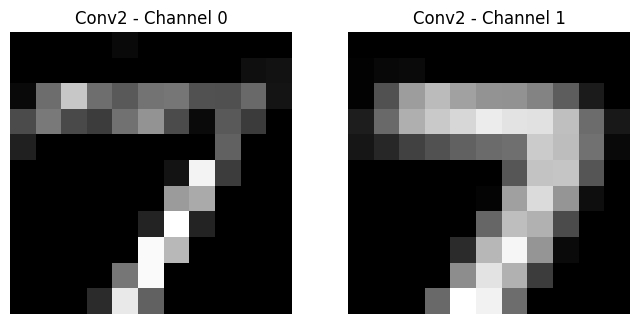

In [19]:
img, label = test_dataset[0]

img = img.unsqueeze(0).to(device)

with torch.no_grad():

    # Conv1
    h1 = torch.relu(model.conv1(img))
    h1_pool = model.pool(h1)

    # Conv2
    h2 = torch.relu(model.conv2(h1_pool))

print("Conv1 shape:", h1.shape)
print("Conv2 shape:", h2.shape)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(h2[0,0].cpu(), cmap='gray')
plt.title("Conv2 - Channel 0")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(h2[0,1].cpu(), cmap='gray')
plt.title("Conv2 - Channel 1")
plt.axis("off")

plt.show()

Feature maps của tầng conv1 chủ yếu phát hiện các đặc trưng cơ bản như cạnh, đường thẳng và các vùng tương phản sáng tối.

Feature maps của tầng conv2 được tạo ra từ đầu ra của conv1 nên chứa thông tin ở mức trừu tượng cao hơn. Một số kênh làm nổi bật các nét cong, các vùng đặc trưng hoặc hình dạng tổng quát của chữ số.

Do đó, conv1 học các đặc trưng mức thấp (low-level features), còn conv2 học các đặc trưng mức cao hơn (high-level features). Điều này phù hợp với nguyên lý hoạt động của CNN khi các tầng sâu dần xây dựng biểu diễn ngày càng phức tạp từ các đặc trưng đơn giản ở tầng trước.

**Câu 5: Thêm Dropout và Data Augmentation**

* Thêm nn.Dropout(p=0.25) sau pool cuối cùng và trước fc1.
* Thêm augmentation vào transform lúc train: transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)). Lưu ý: chỉ áp dụng cho train, KHÔNG áp dụng cho test.
* Train 10 epoch, so sánh test acc với mô hình không có dropout/augmentation.

In [23]:
train_transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=10,
        translate=(0.1, 0.1)
    ),
    transforms.ToTensor(),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=train_transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')


Số ảnh train: 60000,  test: 10000


In [31]:
class MNIST_CNN_dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.25)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.dropout(x)
        x = self.fc1(x)                            # logits
        return x

model1 = MNIST_CNN_dropout().to(device)
n_params = sum(p.numel() for p in model1.parameters() if p.requires_grad)
print(model1)
print(f'Tổng tham số: {n_params:,}')

# So sánh nhanh với ANN(784→128→10) ở bài trước: ~101 nghìn params và ~97% acc.
# CNN này thường ít tham số hơn (~13 nghìn) mà acc cao hơn.

MNIST_CNN_dropout(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Tổng tham số: 12,810


In [29]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

In [30]:
model = MNIST_CNN_dropout().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

num_epochs = 10
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

Epoch 1/10  train_loss=0.6320  train_acc=79.55%  test_loss=0.1032  test_acc=97.11%
Epoch 2/10  train_loss=0.2702  train_acc=91.83%  test_loss=0.0702  test_acc=97.90%
Epoch 3/10  train_loss=0.2163  train_acc=93.38%  test_loss=0.0597  test_acc=98.13%
Epoch 4/10  train_loss=0.1894  train_acc=94.22%  test_loss=0.0473  test_acc=98.55%
Epoch 5/10  train_loss=0.1686  train_acc=94.84%  test_loss=0.0400  test_acc=98.68%
Epoch 6/10  train_loss=0.1562  train_acc=95.23%  test_loss=0.0454  test_acc=98.57%
Epoch 7/10  train_loss=0.1443  train_acc=95.57%  test_loss=0.0388  test_acc=98.92%
Epoch 8/10  train_loss=0.1321  train_acc=95.97%  test_loss=0.0378  test_acc=98.80%
Epoch 9/10  train_loss=0.1298  train_acc=96.02%  test_loss=0.0317  test_acc=99.01%
Epoch 10/10  train_loss=0.1271  train_acc=96.18%  test_loss=0.0339  test_acc=98.92%


CNN gốc: Epoch 10:train_loss=0.0183, train_acc=99.44%, test_loss=0.0330, test_acc=98.94%, GAP: 0.5%

CNN_dropout_augment: Epoch 10:train_loss=0.1271, train_acc=96.18%, test_loss=0.0339, test_acc=98.92%, GAP: 2.74%

Nhận xét: train_acc giảm, test_acc tương đương=>chứng minh giảm overfitting.

**Trực quan: model dự đoán**

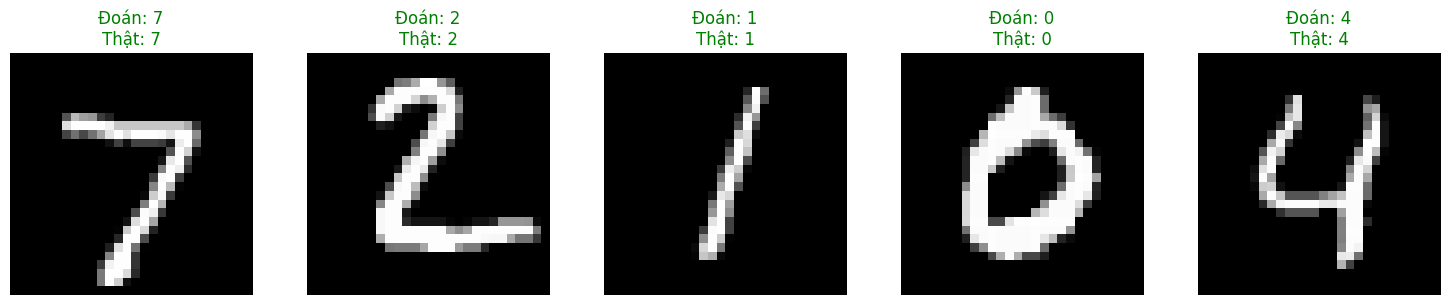

In [15]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].cpu().squeeze() * 0.3081 + 0.1307   # un-normalize để nhìn cho đẹp
    axes[i].imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'Đoán: {preds[i].item()}\nThật: {labels[i].item()}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

**Trực quan: feature maps**

Nhìn xem các filter của tầng conv1 đã học được điều gì.

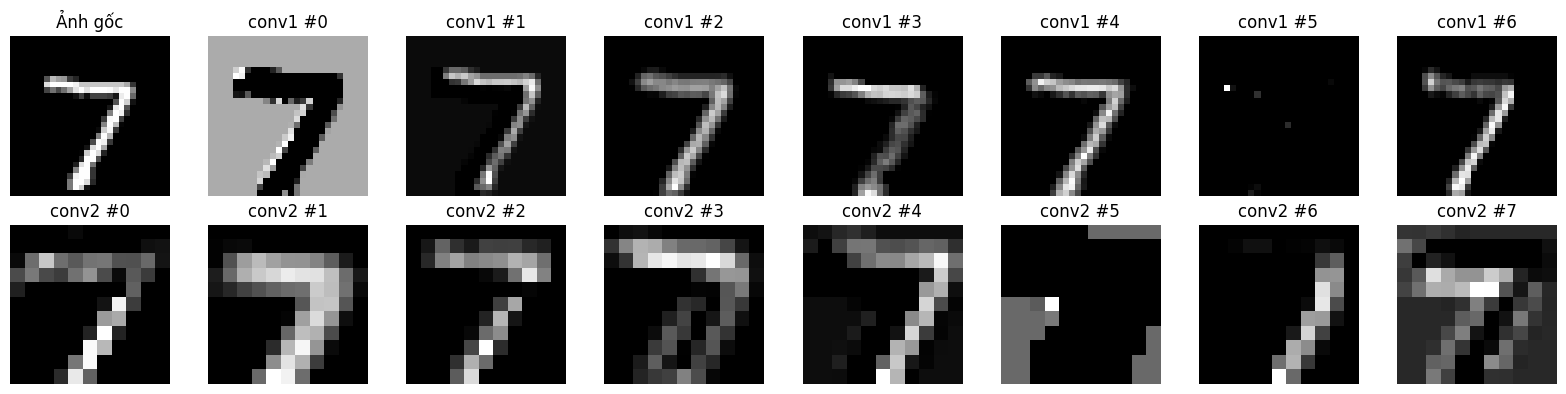

Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.
         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)


In [16]:

model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap1 = torch.relu(model.conv1(img))           # (1, 16, 26, 26)
    fmap2 = torch.relu(model.conv2(model.pool(fmap1)))  # (1, 32, 11, 11)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title('Ảnh gốc'); axes[0, 0].axis('off')
for i in range(7):
    axes[0, i+1].imshow(fmap1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}'); axes[0, i+1].axis('off')
for i in range(8):
    axes[1, i].imshow(fmap2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

print('Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.')
print('         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)')